In [1]:
import zipfile
import os

# Path to zip file in Drive
zip_path = '/content/drive/MyDrive/Brain_Tumor_Dataset/archive.zip'
extract_path = '/content/dataset'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction complete!")
print(os.listdir(extract_path))

Extraction complete!
['yes', 'brain_tumor_dataset', 'no']


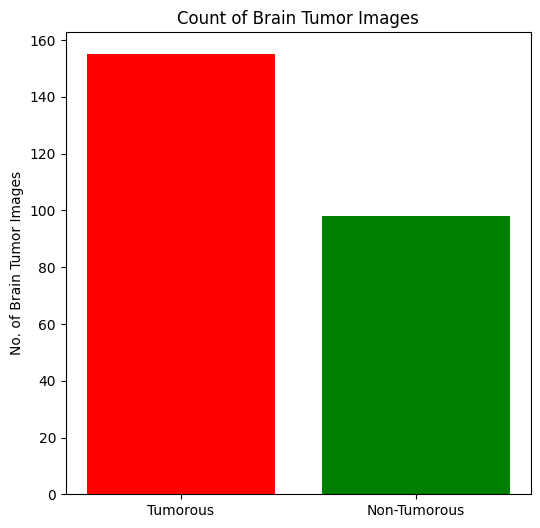

Total images: 253


In [2]:
import os
import matplotlib.pyplot as plt

base_dir = '/content/dataset/brain_tumor_dataset/'
categories = ['yes', 'no']

for cat in categories:
    folder = os.path.join(base_dir, cat)
    count = 1
    for filename in os.listdir(folder):
        if filename.lower().endswith(('.jpg', '.png', '.jpeg')):
            suffix = 'Y' if cat == 'yes' else 'N'
            new_name = f"{suffix}_{count}.jpg"
            os.rename(os.path.join(folder, filename), os.path.join(folder, new_name))
            count += 1

# Data for Bar Graph
num_yes = len(os.listdir(os.path.join(base_dir, 'yes')))
num_no = len(os.listdir(os.path.join(base_dir, 'no')))

plt.figure(figsize=(6, 6))
plt.bar(['Tumorous', 'Non-Tumorous'], [num_yes, num_no], color=['red', 'green'])
plt.ylabel("No. of Brain Tumor Images")
plt.title("Count of Brain Tumor Images")
plt.show()

print(f"Total images: {num_yes + num_no}")

In [3]:
import shutil
import numpy as np

processed_dir = '/content/brain_tumor_processed'
train_dir = os.path.join(processed_dir, 'train')
val_dir = os.path.join(processed_dir, 'val')

for folder in [train_dir, val_dir]:
    for sub in ['yes', 'no']:
        os.makedirs(os.path.join(folder, sub), exist_ok=True)

def split_data(cat):
    src = os.path.join(base_dir, cat)
    files = os.listdir(src)
    np.random.shuffle(files)
    split = int(len(files) * 0.8)

    for i, f in enumerate(files):
        dest = train_dir if i < split else val_dir
        shutil.copy(os.path.join(src, f), os.path.join(dest, cat, f))

split_data('yes')
split_data('no')
print("Data Split Successfully (80% Train, 20% Val)")

Data Split Successfully (80% Train, 20% Val)


In [4]:
import cv2
import imutils

def crop_brain_contour(image):
    # FIX: Ensure image is 8-bit integer for OpenCV
    if image.max() <= 1.0:
        image = (image * 255).astype('uint8')
    else:
        image = image.astype('uint8')

    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    gray = cv2.GaussianBlur(gray, (5, 5), 0)
    thresh = cv2.threshold(gray, 45, 255, cv2.THRESH_BINARY)[1]
    thresh = cv2.erode(thresh, None, iterations=2)
    thresh = cv2.dilate(thresh, None, iterations=2)

    cnts = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cnts = imutils.grab_contours(cnts)

    if len(cnts) > 0:
        c = max(cnts, key=cv2.contourArea)
        extLeft = tuple(c[c[:, :, 0].argmin()][0])
        extRight = tuple(c[c[:, :, 0].argmax()][0])
        extTop = tuple(c[c[:, :, 1].argmin()][0])
        extBot = tuple(c[c[:, :, 1].argmax()][0])
        image = image[extTop[1]:extBot[1], extLeft[0]:extRight[0]]

    # Return resized float image (0-1) for the AI
    image = cv2.resize(image, (224, 224))
    return image.astype('float32') / 255.0

In [5]:
from tensorflow.keras.applications import VGG19
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

base_model = VGG19(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(2, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)
model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv4 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 20,156,226 (76.89 MB)

 Trainable params: 131,842 (515.01 KB)

 Non-trainable params: 20,024,384 (76.39 MB)

In [6]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rotation_range=15,
    horizontal_flip=True,
    preprocessing_function=crop_brain_contour
)

val_datagen = ImageDataGenerator(preprocessing_function=crop_brain_contour)

train_gen = train_datagen.flow_from_directory(train_dir, target_size=(224, 224), batch_size=32, class_mode='categorical')
val_gen = val_datagen.flow_from_directory(val_dir, target_size=(224, 224), batch_size=32, class_mode='categorical')

# Start Training
history = model.fit(train_gen, validation_data=val_gen, epochs=20)

Found 202 images belonging to 2 classes.
Found 51 images belonging to 2 classes.
Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 35s 3s/step - accuracy: 0.4802 - loss: 0.8224 - val_accuracy: 0.7059 - val_loss: 0.6819
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 495ms/step - accuracy: 0.5990 - loss: 0.7273 - val_accuracy: 0.6078 - val_loss: 0.6627
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 693ms/step - accuracy: 0.5495 - loss: 0.8076 - val_accuracy: 0.6078 - val_loss: 0.6754
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 491ms/step - accuracy: 0.5891 - loss: 0.7233 - val_accuracy: 0.6078 - val_loss: 0.6499
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 490ms/step - accuracy: 0.5941 - loss: 0.6945 - val_accuracy: 0.6078 - val_loss: 0.6382
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 640ms/step - accuracy: 0.5891 - loss: 0.7199 - val_accuracy: 0.6275 - val_loss: 0.6335
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 506ms/step - accuracy: 0.5446 - loss: 0.7476 - val_accuracy: 0.6275 - val_loss: 0.6265
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 

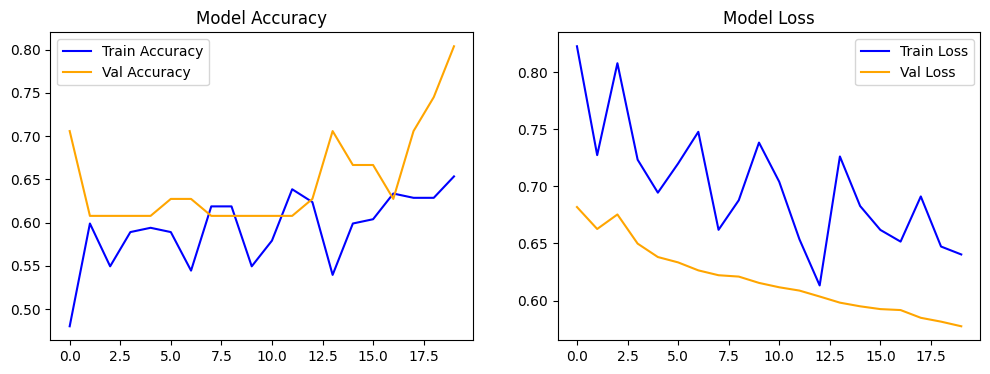

Model saved as brain_tumor_model.h5


In [7]:
plt.figure(figsize=(12, 4))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Val Accuracy', color='orange')
plt.title('Model Accuracy')
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Val Loss', color='orange')
plt.title('Model Loss')
plt.legend()

plt.show()

# Save final model
model.save('brain_tumor_model.h5')
print("Model saved as brain_tumor_model.h5")

In [9]:
# Unfreeze the last block of VGG19 for better accuracy
for layer in base_model.layers[-5:]:
    layer.trainable = True

# Re-compile with a very small learning rate
model.compile(optimizer=Adam(learning_rate=0.00001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train for 10 more epochs to "Fine-Tune" the brain textures
print("Fine-tuning the model for better accuracy...")
model.fit(train_gen, validation_data=val_gen, epochs=10)

# Save the improved model
model.save('brain_tumor_improved.h5')

Fine-tuning the model for better accuracy...
Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.6386 - loss: 0.6474 - val_accuracy: 0.8039 - val_loss: 0.5773
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 842ms/step - accuracy: 0.6634 - loss: 0.6362 - val_accuracy: 0.8039 - val_loss: 0.5769
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 506ms/step - accuracy: 0.6832 - loss: 0.6065 - val_accuracy: 0.7647 - val_loss: 0.5767
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 506ms/step - accuracy: 0.6733 - loss: 0.6400 - val_accuracy: 0.7647 - val_loss: 0.5764
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 595ms/step - accuracy: 0.6337 - loss: 0.6512 - val_accuracy: 0.7647 - val_loss: 0.5761
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 610ms/step - accuracy: 0.6287 - loss: 0.6409 - val_accuracy: 0.7647 - val_loss: 0.5760
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 584ms/step - accuracy: 0.6782 - loss: 0.5901 - val_accuracy: 0.7451 - val_loss: 0.5760
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 520ms/step - accuracy: 0.7030 - loss:

In [11]:
print(train_gen.class_indices)

{'no': 0, 'yes': 1}


In [12]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

# 1. Unfreeze more of the VGG19 model to let it learn deeper features
for layer in base_model.layers[-8:]:
    layer.trainable = True

# 2. Use a slightly higher learning rate for a faster "jump" in learning
model.compile(optimizer=Adam(learning_rate=1e-5),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# 3. Add a callback that slows down learning if the model gets stuck
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-7)

# 4. Train for 15 more epochs
print("Training deeper to improve confidence...")
history_fine = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15,
    callbacks=[reduce_lr]
)

model.save('brain_tumor_final.h5')

Training deeper to improve confidence...
Epoch 1/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 999ms/step - accuracy: 0.6931 - loss: 0.6144 - val_accuracy: 0.7451 - val_loss: 0.5767 - learning_rate: 1.0000e-05
Epoch 2/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 754ms/step - accuracy: 0.6634 - loss: 0.6143 - val_accuracy: 0.7451 - val_loss: 0.5768 - learning_rate: 1.0000e-05
Epoch 3/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 548ms/step - accuracy: 0.6485 - loss: 0.6472 - val_accuracy: 0.7255 - val_loss: 0.5767 - learning_rate: 1.0000e-05
Epoch 4/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 510ms/step - accuracy: 0.6386 - loss: 0.6529 - val_accuracy: 0.7451 - val_loss: 0.5766 - learning_rate: 2.0000e-06
Epoch 5/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 518ms/step - accuracy: 0.6584 - loss: 0.6076 - val_accuracy: 0.7451 - val_loss: 0.5764 - learning_rate: 2.0000e-06
Epoch 6/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 714ms/step - accuracy: 0.7079 - loss: 0.5791 - val_accuracy: 0.7451 - val_loss: 0.5763 - learning_rate: 2.0000e-06
Epoch 7/15
7/7 ━━━━━━━━━━━━━━━━━━━

In [14]:
import gradio as gr
import tensorflow as tf
import numpy as np
import cv2
import imutils

# Load the improved model
model = tf.keras.models.load_model('brain_tumor_improved.h5')

def predict_tumor(input_img):
    # Preprocessing
    img = input_img.astype('uint8')
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    gray = cv2.GaussianBlur(gray, (5, 5), 0)
    thresh = cv2.threshold(gray, 45, 255, cv2.THRESH_BINARY)[1]
    thresh = cv2.erode(thresh, None, iterations=2)
    thresh = cv2.dilate(thresh, None, iterations=2)

    cnts = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cnts = imutils.grab_contours(cnts)

    if len(cnts) > 0:
        c = max(cnts, key=cv2.contourArea)
        extLeft = tuple(c[c[:, :, 0].argmin()][0])
        extRight = tuple(c[c[:, :, 0].argmax()][0])
        extTop = tuple(c[c[:, :, 1].argmin()][0])
        extBot = tuple(c[c[:, :, 1].argmax()][0])
        img = img[extTop[1]:extBot[1], extLeft[0]:extRight[0]]

    img = cv2.resize(img, (224, 224))
    img = img.astype('float32') / 255.0
    img = np.expand_dims(img, axis=0)

    # Make Prediction
    prediction = model.predict(img)[0]
    result_index = np.argmax(prediction) # Get the index of the highest probability
    confidence = prediction[result_index] * 100

    if result_index == 1:
        return f"RESULT: Tumor Detected (Confidence: {confidence:.2f}%)"
    else:
        return f"RESULT: No Tumor Detected / Healthy (Confidence: {confidence:.2f}%)"

# Launch the Interface with a Textbox output
interface = gr.Interface(
    fn=predict_tumor,
    inputs=gr.Image(),
    outputs=gr.Textbox(label="Diagnosis Result"),
    title="AI Brain Tumor Diagnostic System",
    description="Upload an MRI scan. The system will analyze the brain structure to detect abnormalities.",
    theme="soft"
)

interface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://4dbbe635e094fffd58.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [16]:
from google.colab import files
files.download('brain_tumor_final.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>